# Graphs for Demand Exercise

NOTE: The scripts below requires python and an installation of the pybalmorel module. This module is very new, so be critical. Feel free to post issues [here](https://github.com/Mathias157/pybalmorel/issues)

**Installation:**

Open a terminal, activate your virtual environment and write:

`pip install pybalmorel`

## Loading Results

In [15]:
!pip install pybalmorel

In [16]:
import pybalmorel 
import matplotlib.pyplot as plt

In [17]:
from pybalmorel import MainResults
from pybalmorel.formatting import balmorel_colours

# Write the exact names of the scenarios and the path (or paths) that they aC:\\Users\\Bruger\\OneDrive\\Documents\\Master\\4. June 2026\\Large scale energy system analysis\\Excersice\\Lecture_2\\BalmorelSimpleModel_LP\\BalmorelSimpleModel_LP\\Balmorel\\Lecture_2_Ex_0\\model\\re in
res = MainResults(files=["1.gdx", "2.gdx", "3.gdx", "4.gdx", "Base.gdx", "2025.gdx"
                                                  ], 
                  paths='C:\\Users\\Bruger\\OneDrive\\Documents\\Master\\4. June 2026\\Large scale energy system analysis\\LSESAub\\0_results_for_python')

Loading C:\Users\Bruger\OneDrive\Documents\Master\4. June 2026\Large scale energy system analysis\LSESAub\0_results_for_python\1.gdx
Loading C:\Users\Bruger\OneDrive\Documents\Master\4. June 2026\Large scale energy system analysis\LSESAub\0_results_for_python\2.gdx
Loading C:\Users\Bruger\OneDrive\Documents\Master\4. June 2026\Large scale energy system analysis\LSESAub\0_results_for_python\3.gdx
Loading C:\Users\Bruger\OneDrive\Documents\Master\4. June 2026\Large scale energy system analysis\LSESAub\0_results_for_python\4.gdx
Loading C:\Users\Bruger\OneDrive\Documents\Master\4. June 2026\Large scale energy system analysis\LSESAub\0_results_for_python\Base.gdx
Loading C:\Users\Bruger\OneDrive\Documents\Master\4. June 2026\Large scale energy system analysis\LSESAub\0_results_for_python\2025.gdx


c:\Users\Bruger\miniforge3\envs\anaconda3\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (54.0.0) differs from the API version (53.5.1).
  ws = gams.GamsWorkspace()


## Plotting Objective Function

Index(['Scenario', 'Year', 'Country', 'From', 'To', 'Category', 'Unit',
       'Value'],
      dtype='str')


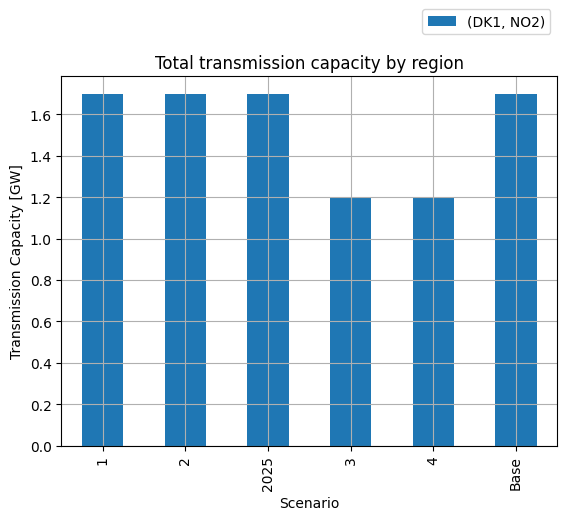

In [18]:
obj_emi = res.get_result('X_CAP_YCR')

# Print columns of obj_emi
print(obj_emi.columns)

# Aggregate
#Show transmission from region to region, I want only NO2 to DK1
obj_emi = obj_emi[(obj_emi['From'] == 'NO2') & (obj_emi['To'] == 'DK1')]
obj_emi = obj_emi.pivot_table(index='Scenario', 
                columns=['To', 'From'],  
                values='Value',
                aggfunc='sum')

# Plot
ax = obj_emi.plot(kind='bar', stacked=True, ylabel='Transmission Capacity [GW]', grid=True)
ax.set_title('Total transmission capacity by region')
ax.legend(bbox_to_anchor=(1, 1.2), ncols=4)

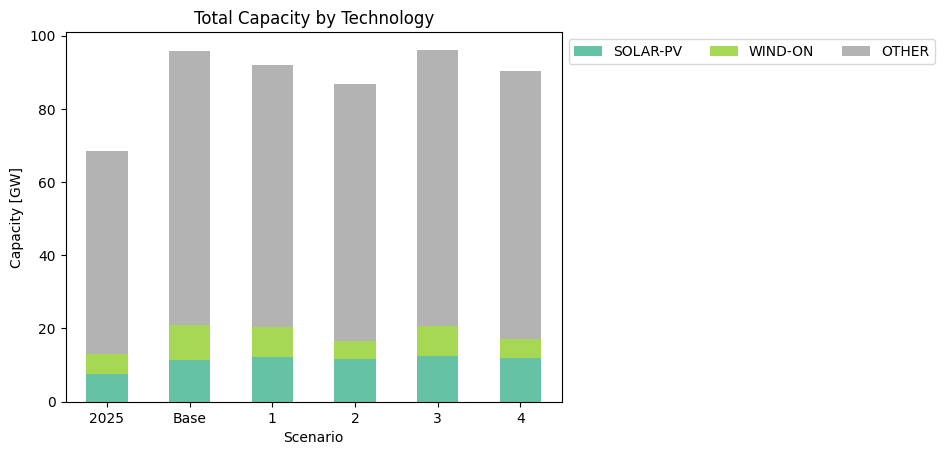

In [19]:
obj = res.get_result('G_CAP_YCRAF')

# Aggregate
obj = obj.pivot_table(index='Scenario', 
                      columns=['Technology'],  
                      values='Value',
                      aggfunc='sum')

# Define the target technologies (Note: matching 'HYDRO-RESERVOIRS' to your original image legend)
target_techs = ['SOLAR-PV', 'WIND-ON']

# 1. Sum up all other columns into 'OTHER'
obj['OTHER'] = obj.loc[:, ~obj.columns.isin(target_techs)].sum(axis=1)

# 2. Keep ONLY the target technologies + 'OTHER'
obj = obj[target_techs + ['OTHER']]

# Make the order of scenarios correct
obj = obj.reindex(['2025', 'Base', '1', '2', '3', '4'])

# Choose a colormap like 'viridis', 'Set2', 'tab10', 'Pastel1', or 'coolwarm'
cmap = plt.colormaps['Set2'] 
num_colors = len(obj.columns)
color_list = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Plot using the color list
ax = obj.plot(kind='bar', stacked=True, ylabel='Capacity [GW]', rot=0, 
              color=color_list) 
ax.set_title('Total Capacity by Technology')
ax.legend(bbox_to_anchor=(1, 1), ncols=3)

In [20]:
print(obj)

Technology   SOLAR-PV   WIND-ON      OTHER
Scenario                                  
2025         7.492306  5.674378  55.439813
Base        11.360717  9.549419  74.890854
1           12.110904  8.200000  71.682759
2           11.627157  5.092305  70.162002
3           12.617967  8.200000  75.322023
4           12.000000  5.000000  73.318642


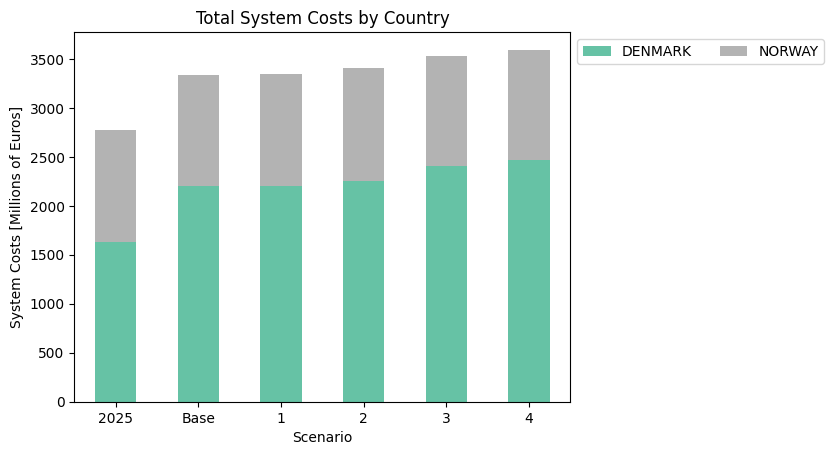

In [21]:
obj = res.get_result('OBJ_YCR')

# Aggregate
obj = obj.pivot_table(index='Scenario', 
                columns=['Country'],  
                values='Value',
                aggfunc='sum')

# Make the order of scenarios correct
obj = obj.reindex(['2025', 'Base', '1', '2', '3', '4'])

# Choose a colormap like 'viridis', 'Set2', 'tab10', 'Pastel1', or 'coolwarm'
cmap = plt.colormaps['Set2'] 
num_colors = len(obj.columns)
color_list = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Plot using the color list
ax = obj.plot(kind='bar', stacked=True, ylabel='System Costs [Millions of Euros]', rot=0, 
              color=color_list) 
ax.set_title('Total System Costs by Country')
ax.legend(bbox_to_anchor=(1, 1), ncols=4)

In [22]:
print(obj)

Country       DENMARK       NORWAY
Scenario                          
2025      1630.816499  1146.036438
Base      2202.792167  1137.122252
1         2203.465499  1143.273539
2         2257.975889  1150.965408
3         2407.322718  1122.487915
4         2465.871449  1127.348114


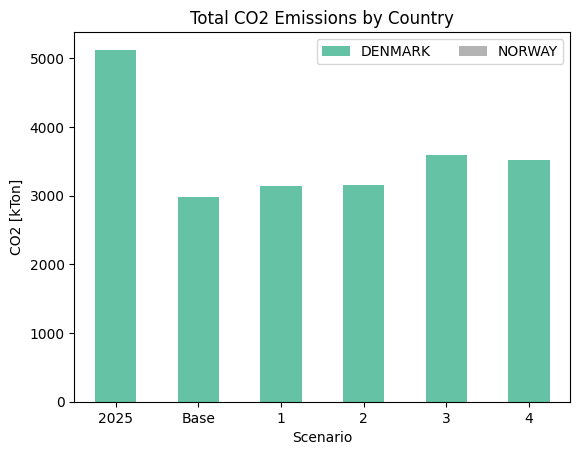

In [23]:
obj = res.get_result('EMI_YCRAG')

# Aggregate
obj = obj.pivot_table(index='Scenario', 
                      columns=['C'],  
                      values='Value',
                      aggfunc='sum')

# Make the order of scenarios correct
obj = obj.reindex(['2025', 'Base', '1', '2', '3', '4'])

# Choose a colormap like 'viridis', 'Set2', 'tab10', 'Pastel1', or 'coolwarm'
cmap = plt.colormaps['Set2'] 
num_colors = len(obj.columns)
color_list = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Plot using the color list
ax = obj.plot(kind='bar', stacked=True, ylabel='CO2 [kTon]', rot=0, 
              color=color_list) 
ax.set_title('Total CO2 Emissions by Country')
ax.legend(bbox_to_anchor=(1, 1), ncols=4)

In [24]:
print(obj)

C             DENMARK        NORWAY
Scenario                           
2025      5126.638367  9.635022e-01
Base      2978.054740 -3.498389e-15
1         3147.210583 -2.629586e-14
2         3159.065637  8.171229e-16
3         3588.829873  2.424970e-01
4         3526.944334  2.424970e-01


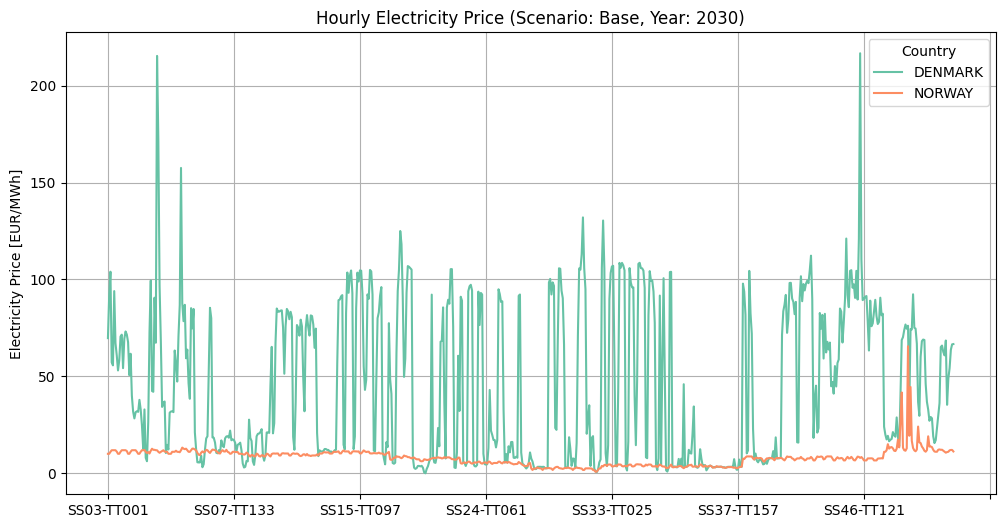

In [25]:
# 1. Pull raw Balmorel GDX results
obj = res.get_result('EL_PRICE_YCRST')

# METHOD B: Remove any row where the price is greater than 1000
obj = obj[obj['Value'] <= 300]

# 3. Pivot with Time dimensions as rows, and Countries as columns
hourly_prices = obj.pivot_table(
    index=['Season', 'Time'],  # This preserves the chronological time order
    columns=['Country'],  
    values='Value',
    aggfunc='mean'             # Use mean instead of sum in case of duplicate entries
)

# 4. Optional: Flatten the MultiIndex so pandas can plot it sequentially on the x-axis
hourly_prices.index = [f"S{s}-T{t}" for s, t in hourly_prices.index]

# 5. Plot the profile
cmap = plt.colormaps['Set2']
ax = hourly_prices.plot(kind='line', ylabel='Electricity Price [EUR/MWh]', color=cmap.colors, figsize=(12, 6))
ax.set_title('Hourly Electricity Price (Scenario: Base, Year: 2030)')
plt.grid(True)

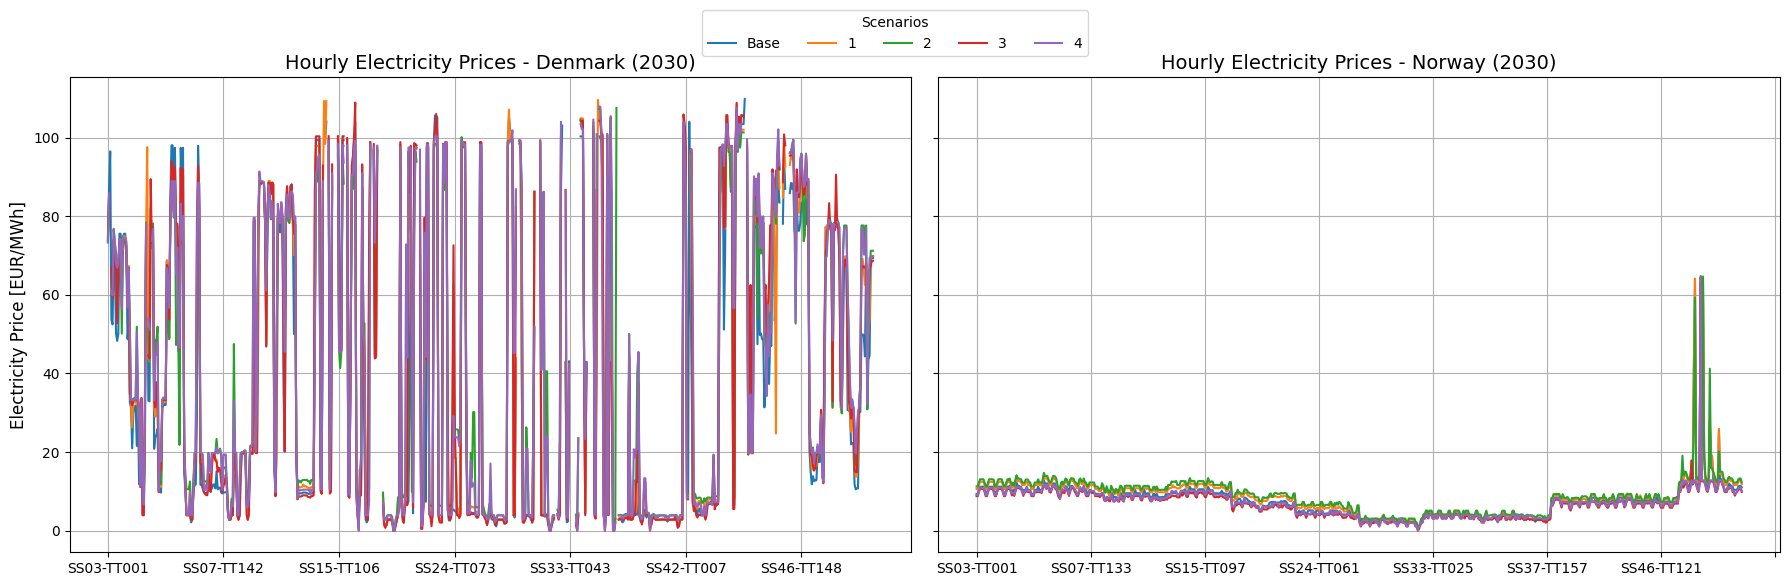

In [26]:
# 1. Pull raw Balmorel GDX results
obj = res.get_result('EL_PRICE_YCRST')

# 2. Basic cleaning: Filter for your target year and clean up extreme price spikes
obj = obj[obj['Value'] <= 110]

# --- Setup the two side-by-side plots ---
fig, (ax_dk, ax_nor) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
cmap = plt.colormaps['tab10']

# Define custom ordered list for scenario lines
scenario_order = ['Base', '1', '2', '3', '4']

# ==========================================
# PLOT 1: DENMARK
# ==========================================
# (Note: Check if your GDX uses 'DENMARK' or 'DK' based on your previous print)
obj_dk = obj[obj['Country'] == 'DENMARK']

prices_dk = obj_dk.pivot_table(
    index=['Season', 'Time'], 
    columns=['Scenario'], 
    values='Value', 
    aggfunc='mean'
).reindex(columns=scenario_order)

prices_dk.index = [f"S{s}-T{t}" for s, t in prices_dk.index]

prices_dk.plot(kind='line', ax=ax_dk, color=cmap.colors)
ax_dk.set_title('Hourly Electricity Prices - Denmark (2030)', fontsize=14)
ax_dk.set_ylabel('Electricity Price [EUR/MWh]', fontsize=12)
ax_dk.grid(True)
ax_dk.get_legend().remove() # Remove temporary legend to clean up spacing

# ==========================================
# PLOT 2: NORWAY
# ==========================================
# (Note: Check if your GDX uses 'NORWAY' or 'NO')
obj_nor = obj[obj['Country'] == 'NORWAY']

prices_nor = obj_nor.pivot_table(
    index=['Season', 'Time'], 
    columns=['Scenario'], 
    values='Value', 
    aggfunc='mean'
).reindex(columns=scenario_order)

prices_nor.index = [f"S{s}-T{t}" for s, t in prices_nor.index]

prices_nor.plot(kind='line', ax=ax_nor, color=cmap.colors)
ax_nor.set_title('Hourly Electricity Prices - Norway (2030)', fontsize=14)
ax_nor.grid(True)
ax_nor.get_legend().remove()

# ==========================================
# SHARED LEGEND
# ==========================================
# Place a single clean legend for the scenarios at the top or side
handles, labels = ax_dk.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncols=6, title="Scenarios")

plt.tight_layout(rect=[0, 0, 1, 0.92]) # Make room for the header legend
plt.show()

## Plotting Profiles

(0.0, 42.0)

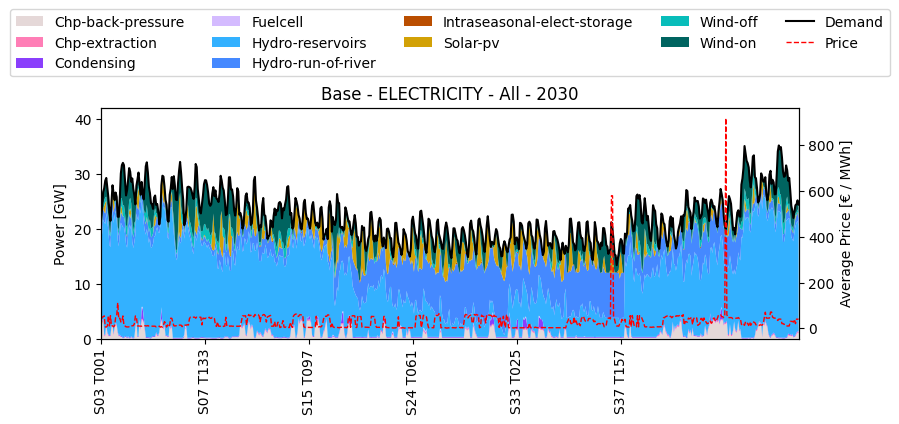

In [27]:
fig, ax = res.plot_profile('Electricity', 2030, scenario='Base')
ax.set_ylim([0, 42])




In [28]:
fig, ax = res.plot_profile('Heat', 2050, scenario='base')
ax.set_ylim([0, 42])
fig, ax = res.plot_profile('Heat', 2050, scenario='netzero')
ax.set_ylim([0, 42])
fig, ax = res.plot_profile('Heat', 2050, scenario='netnegative')
ax.set_ylim([0, 42])

KeyError: 'base'

(0.0, 42.0)

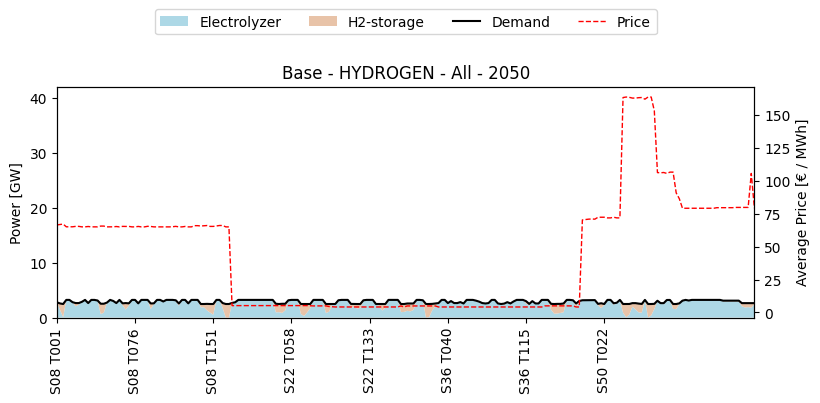

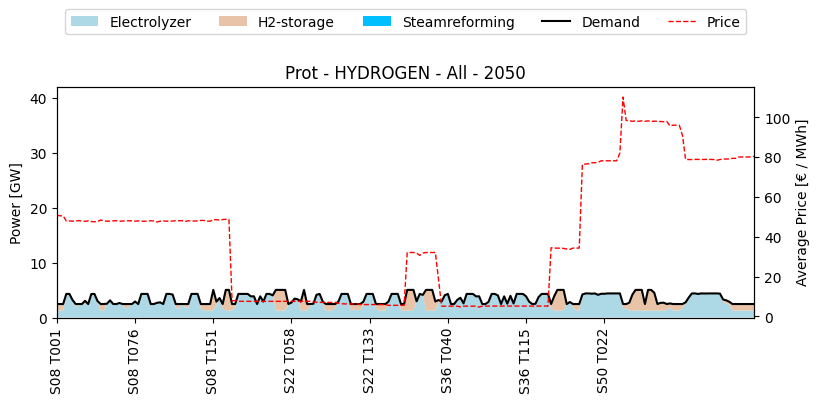

In [ ]:
fig, ax = res.plot_profile('Hydrogen', 2050, scenario='Base')
ax.set_ylim([0, 42])
fig, ax = res.plot_profile('Hydrogen', 2050, scenario='Prot')
ax.set_ylim([0, 42])